In [1]:
import numpy as np, matplotlib.pyplot as plt, pandas as pd

## Baseline

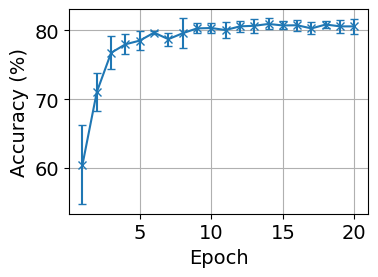

In [2]:
plt.figure(figsize=(4, 3))
plt.rcParams.update({"font.size": 14})

df = pd.read_csv("../../results/postprocessing/plot_baseline.csv")

epochs    = df["epochs"].values
mean_acc  = df["mean"].values
std_acc   = df["std"].values

plt.errorbar(epochs, mean_acc, yerr=std_acc, marker="x", capsize=3)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)

plt.tight_layout()
plt.savefig("../../results/figures/val_acc_over_epochs.svg")
plt.show()

## Accuracy vs q without noise

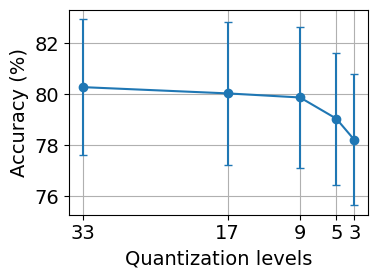

In [3]:
plt.figure(figsize=(4, 3))
plt.rcParams.update({"font.size": 14})

df = pd.read_csv("../../results/postprocessing/plot_acc_vs_q_no_noise.csv")

q_values    = df["q_values"].values
mean_acc_2  = df["mean_acc_2"].values
std_acc_2   = df["std_acc_2"].values

q_values_compute = np.array([2, 4, 8, 16, 32])

plt.errorbar(q_values + 1, mean_acc_2, yerr=std_acc_2, marker="o", capsize=3, label="2-class")

plt.xlabel("Quantization levels")
plt.xticks(q_values_compute + 1)
plt.ylabel("Accuracy (%)")
# plt.ylim(70.0, 85.0)
plt.grid(True)
plt.gca().invert_xaxis()
# plt.legend(loc="best")

plt.tight_layout()
plt.show()

## Accuracy vs q with noise

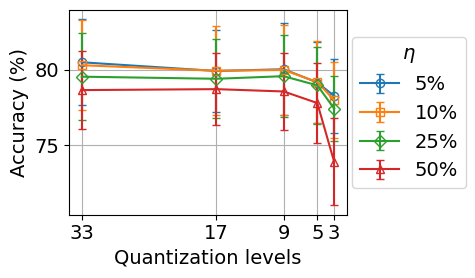

In [4]:
q_values_compute = np.array([2, 4, 8, 16, 32])
x_vals_plot = [2.0, 4.0, 10.0, 20.0]
x_values = [2.0, 4.0, 10.0, 20.0]

# Distinct line styles for exactly 5 curves
linestyles = ["-", "--", "-.", ":", (0, (3, 5, 1, 5))]

# Distinct markers for exactly 5 curves
markers = ["o", "s", "D", "^", "v"]

plt.rcParams.update({"font.size": 14})
fig, ax = plt.subplots(figsize=(5, 3))

i = -1
for x in sorted(x_values, reverse=True):
    if x not in x_vals_plot:
        continue

    df = pd.read_csv(f"../../results/postprocessing/plot_acc_vs_q_with_noise_x_{x}.csv")

    q_vals    = df["q_vals"].values
    mean_x  = df["mean_x"].values
    std_x   = df["std_x"].values
    rsd    = 100.0 / x

    i += 1
    style  = linestyles[i]
    marker = markers[i]

    ax.errorbar(q_vals + 1, mean_x, yerr=std_x, marker=marker,
                markerfacecolor="none", markersize=6,
                linewidth=1.5, capsize=3, label=f"{rsd:.0f}%")

ax.set_xlabel("Quantization levels")
ax.set_xticks(q_values_compute + 1)
ax.set_ylabel("Accuracy (%)")
ax.grid(True)
ax.invert_xaxis()
ax.legend(title=r"$\eta$", bbox_to_anchor=(1.02, 0.5),
          loc="center left", borderaxespad=0.0)

plt.tight_layout()
plt.show()

## Fine-tuning

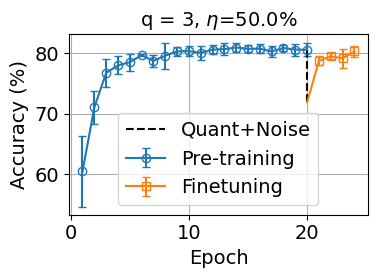

In [5]:
plt.rcParams.update({"font.size": 14})
fig, ax = plt.subplots(figsize=(4, 3))

x = 2.0

df_pre = pd.read_csv(f"../../results/postprocessing/plot_finetune_pre_x_{x}.csv")

x_pre = df_pre["x_pre"].values
mean_pre = df_pre["mean_pre"].values
std_pre = df_pre["std_pre"].values

df_ft = pd.read_csv(f"../../results/postprocessing/plot_finetune_ft_x_{x}.csv")

x_ft_plot = df_ft["x_ft_plot"].values
mean_ft_plot = df_ft["mean_ft_plot"].values
std_ft_plot = df_ft["std_ft_plot"].values

df_q = pd.read_csv(f"../../results/postprocessing/plot_finetune_quant_x_{x}.csv")

x_pre_end  = float(df_q["x_pre_end"].iloc[0])
q_acc_mean = float(df_q["q_acc_mean"].iloc[0])

# pretraining curve
ax.errorbar(x_pre, mean_pre, yerr=std_pre, marker="o", markerfacecolor="none", capsize=3, linewidth=1.5, label="Pre-training")

# vertical drop for quant+noise at the boundary epoch
ax.plot([x_pre_end, x_pre_end], [mean_pre[-1], q_acc_mean], "k--", label="Quant+Noise")

# connect bottom of the drop to first finetuning point (no marker here)
ax.plot([x_pre_end, x_ft_plot[0]], [q_acc_mean, mean_ft_plot[0]], color="C1", linewidth=1.5)

# finetuning recovery curve (starting at next epoch index)
ax.errorbar(x_ft_plot, mean_ft_plot, yerr=std_ft_plot, marker="s", markerfacecolor="none", capsize=3, linewidth=1.5, label="Finetuning")

ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy (%)")
ax.grid(True)
ax.set_title(f"q = 3, $\\eta$={1/x*100}%", fontsize=14)
ax.legend(loc="lower center")

plt.tight_layout()
plt.show()

## Sweeps

{'thr': 0.025}
{'thr': 0.05}
{'thr': 0.075}


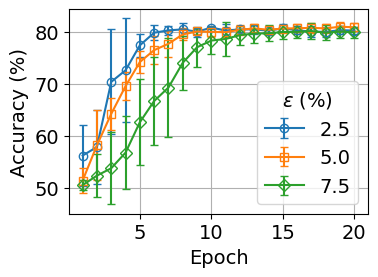

In [6]:
plt.rcParams.update({"font.size": 14})
fig, ax = plt.subplots(figsize=(4, 3))

sweep_param="thr" # Take whatever needed
sweep_values=[0.025, 0.05, 0.075] # Here too
fixed_config = {}

markers = ["o", "s", "D"]
i = 0

for val in sweep_values:
    # build kwargs for the loader: swept param + any fixed config
    cfg = dict(fixed_config)
    cfg[sweep_param] = val
    print(cfg)

    df_ft = pd.read_csv(f"../../results/postprocessing/plot_sweep_{sweep_param}_{val}.csv")

    x_plot = df_ft["x_plot"].values
    mean_plot = df_ft["mean_plot"].values
    std_plot = df_ft["std_plot"].values

    marker = markers[i]
    if sweep_param == "thr_asym":
        label = f"{val}"
    elif sweep_param == "q" and val == 0:
        label = "no re-quant"
    elif sweep_param == "q":
        label = f"{val+1}"
    else:
        label = f"{val*100}"
    ax.errorbar(x_plot, mean_plot, yerr=std_plot, marker=marker,
                markerfacecolor="none", capsize=3, linewidth=1.5, label=label)
    i += 1

ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy (%)")

if sweep_param == "thr":
    legend_title = r"$\epsilon$ (%)"
elif sweep_param == "thr_asym":
    legend_title = r"$\epsilon_{\mathrm{asym}}$"
elif sweep_param == "q":
    legend_title = "q"
else:
    legend_title = f"{sweep_param} (%)"
ax.grid(True)
ax.legend(title=legend_title, loc="lower right" if sweep_param != "q" else "center right")

plt.tight_layout()
plt.show()

{'thr_asym': 0.5}
{'thr_asym': 1.0}
{'thr_asym': 2.0}


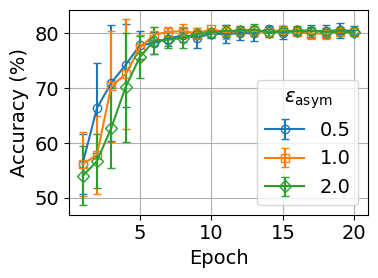

In [7]:
plt.rcParams.update({"font.size": 14})
fig, ax = plt.subplots(figsize=(4, 3))

sweep_param="thr_asym" # Take whatever needed
sweep_values=[0.5, 1.0, 2.0] # Here too
fixed_config = {}

markers = ["o", "s", "D"]
i = 0

for val in sweep_values:
    # build kwargs for the loader: swept param + any fixed config
    cfg = dict(fixed_config)
    cfg[sweep_param] = val
    print(cfg)

    df = pd.read_csv(f"../../results/postprocessing/plot_sweep_{sweep_param}_{val}.csv")

    x_plot = df["x_plot"].values
    mean_plot = df["mean_plot"].values
    std_plot = df["std_plot"].values

    marker = markers[i]
    if sweep_param == "thr_asym":
        label = f"{val}"
    elif sweep_param == "q" and val == 0:
        label = "no re-quant"
    elif sweep_param == "q":
        label = f"{val+1}"
    else:
        label = f"{val*100}"
    ax.errorbar(x_plot, mean_plot, yerr=std_plot, marker=marker,
                markerfacecolor="none", capsize=3, linewidth=1.5, label=label)
    i += 1

ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy (%)")

if sweep_param == "thr":
    legend_title = r"$\epsilon$ (%)"
elif sweep_param == "thr_asym":
    legend_title = r"$\epsilon_{\mathrm{asym}}$"
elif sweep_param == "q":
    legend_title = "q"
else:
    legend_title = f"{sweep_param} (%)"
ax.grid(True)
ax.legend(title=legend_title, loc="lower right" if sweep_param != "q" else "center right")

plt.tight_layout()
plt.show()

## Updates

thr=0.025: final crossings_global=448798
thr=0.05: final crossings_global=230364
thr=0.075: final crossings_global=130705


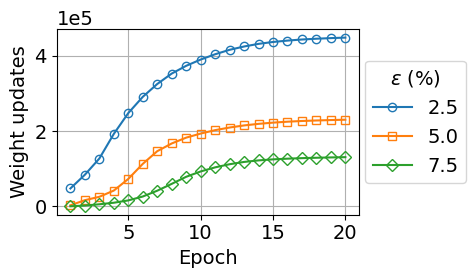

In [8]:
plt.rcParams.update({"font.size": 14})
fig, ax = plt.subplots(figsize=(5, 3))

thr_list = [0.025, 0.05, 0.075]

# scientific notation on y-axis
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

markers = ["o", "s", "D"]
i = 0

for thr in thr_list:
    df = pd.read_csv(f"../../results/postprocessing/plot_updates_thr_{thr}.csv")

    x_plot = df["x_plot"].values
    mean_plot = df["mean_plot"].values
    std_plot = df["std_plot"].values

    marker = markers[i]
    ax.errorbar(x_plot, mean_plot, capsize=3, marker=marker, markerfacecolor="none", linewidth=1.5, label=f"{thr*100}")
    i += 1

    print(f"thr={thr}: final crossings_global={mean_plot[-1]:.0f}")

ax.set_xlabel("Epoch")
ax.set_ylabel("Weight updates")
ax.grid(True)
ax.legend(title=r"$\epsilon$ (%)", bbox_to_anchor=(1.02, 0.5), loc="center left", borderaxespad=0.0)

plt.tight_layout()
plt.savefig("../../results/figures/updates_over_epochs_model_online_thr_sweep.svg")
plt.show()


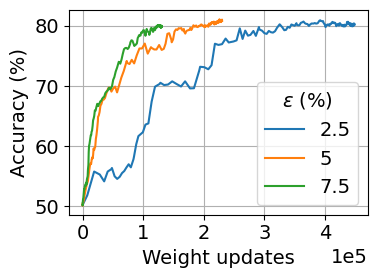

In [9]:
plt.rcParams.update({"font.size": 14})
fig, ax = plt.subplots(figsize=(4, 3))

sweep_values = [0.025, 0.05, 0.075]
sweep_param="thr"

# scientific notation on x-axis
ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))

markers    = ["o", "s", "D"]
linestyles = ["-", "--", "-."]
i = 0

for val in sweep_values:
    cfg = dict(fixed_config)
    cfg[sweep_param] = val

    marker   = markers[i % len(markers)]
    linestyle = linestyles[i % len(linestyles)]
    i += 1

    df = pd.read_csv(f"../../results/postprocessing/plot_updates_acc_{sweep_param}_{val}.csv")

    x_vals = df["x_vals"].values
    mean_acc = df["mean_acc"].values

    # main curve
    ax.plot(
        x_vals, mean_acc,
        label=f"{val*100:g}",
    )

ax.set_xlabel("Weight updates")
ax.set_ylabel("Accuracy (%)")
ax.grid(True)

legend_map = {"thr": r"$\epsilon$ (%)", "thr_asym": r"$\epsilon_{\mathrm{asym}}$"}
legend_title = legend_map.get(sweep_param, sweep_param)
ax.legend(title=legend_title, loc="lower right")

plt.tight_layout()
plt.show()

## Histograms

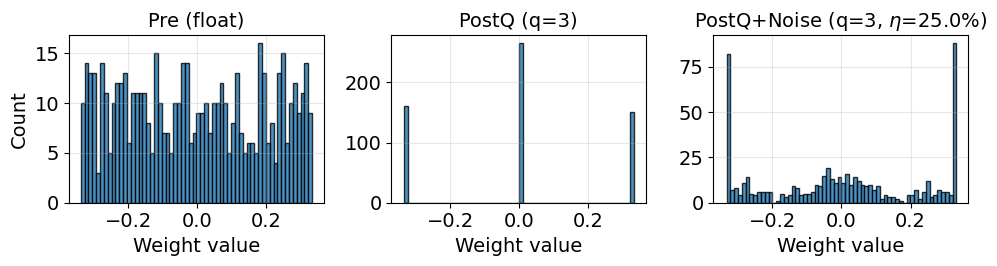

In [11]:
df = pd.read_csv(f"../../results/postprocessing/plot_hists.csv")

q = 2
x = 4.0

w_pre = df["w_pre"].values
w_postq = df["w_postq"].values
w_postqn = df["w_postqn"].values

fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharex=True)  # only share x-axis    
label_fs = 14
tick_fs  = 14    # Auto determine x-axis range from all values
all_vals = np.concatenate([w_pre, w_postq, w_postqn])
xmin, xmax = np.min(all_vals), np.max(all_vals)    # Pre
ax = axes[0]
ax.hist(w_pre, bins=60, alpha=0.8, edgecolor="black")
ax.set_title("Pre (float)", fontsize=label_fs)
ax.set_xlabel("Weight value", fontsize=label_fs)
ax.set_ylabel("Count", fontsize=label_fs)
ax.tick_params(axis="both", labelsize=tick_fs)
# ax.set_xlim(xmin, xmax)
ax.grid(True, alpha=0.3)    # Postq
ax = axes[1]
ax.hist(w_postq, bins=60, alpha=0.8, edgecolor="black")
ax.set_title(f"PostQ (q={q+1})", fontsize=label_fs)
ax.set_xlabel("Weight value", fontsize=label_fs)
ax.tick_params(axis="both", labelsize=tick_fs)
# ax.set_xlim(xmin, xmax)
ax.grid(True, alpha=0.3)    # Postqn
ax = axes[2]
ax.hist(w_postqn, bins=60, alpha=0.8, edgecolor="black")
ax.set_title(f"PostQ+Noise (q={q+1}, $\\eta$={1/x*100}%)", fontsize=label_fs)
ax.set_xlabel("Weight value", fontsize=label_fs)
ax.tick_params(axis="both", labelsize=tick_fs)
# ax.set_xlim(xmin, xmax)
ax.grid(True, alpha=0.3)    

plt.tight_layout(rect=[0, 0, 1, 0.96])       
plt.show()